# 06 - OpenCV Stitcher Baseline

Notebook nay dung `cv2.Stitcher` cua OpenCV de thu ghep panorama tren tung scene trong `data/split`.

Output duoc tach rieng theo cau truc hien tai cua du an:
- panorama: `outputs/openCV/panoramas/`
- log JSON: `outputs/openCV/logs/`

Notebook uu tien thu tu anh trong `meta.json`. Neu scene chua co `meta.json`, notebook fallback sang sort theo ten file.

## Experiment Workflow

Notebook được chia thành nhiều section nhỏ để dễ theo dõi và kiểm tra kết quả:

1. `Imports`: nạp thư viện cần thiết.
2. `Paths`: tìm project root và tạo thư mục output cho OpenCV.
3. `Metadata helpers`: đọc `meta.json` và xác định thứ tự ảnh.
4. `Dataset inventory`: xem nhanh toàn bộ scene và nhãn `success / hard_valid / failure` trước khi chọn scene.
5. `Experiment configuration`: chọn `SCENE_ID`, resize và chế độ stitch.
6. `Image utilities`: resize, đổi màu và thống kê ảnh đầu vào.
7. `Pair diagnostics`: đo chất lượng match giữa từng cặp ảnh liền kề.
8. `Preview`: xem nhanh strip ảnh của một scene.
9. `Scene runner`: chạy OpenCV Stitcher trên một scene và lưu log.
10. `Batch runner`: chạy toàn bộ scene nếu cần.

In [1]:
from pathlib import Path
import sys
import json
import gc
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# OpenCV Stitcher can crash the notebook kernel on some scenes when OpenCL stays enabled.
# We disable it up front so hard scenes fail gracefully with a status code instead of killing Python.
cv2.ocl.setUseOpenCL(False)

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = False

print("OpenCL enabled:", cv2.ocl.useOpenCL())


OpenCL enabled: False


## Section 1: Paths

Cell nay lam 3 viec:
- tim `PROJECT_ROOT`
- tro den dataset da chia split trong `data/split`
- dam bao folder output cho nhanh `openCV` da ton tai

In [2]:
def find_project_root(start: Path) -> Path:
    candidates = [start.resolve(), start.resolve().parent]
    for candidate in candidates:
        if (candidate / "data" / "split").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/split")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_utils.panorama_dataset import list_scene_dirs, ordered_scene_files

SPLIT_ROOT = PROJECT_ROOT / "data" / "split"
SPLITS_TO_STITCH = ["test", "failure_analysis"]
OUTPUT_PANORAMA_DIR = PROJECT_ROOT / "outputs" / "openCV" / "panoramas"
OUTPUT_LOG_DIR = PROJECT_ROOT / "outputs" / "openCV" / "logs"

OUTPUT_PANORAMA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_LOG_DIR.mkdir(parents=True, exist_ok=True)


def iter_scene_sources():
    for split_name in SPLITS_TO_STITCH:
        split_dir = SPLIT_ROOT / split_name
        if not split_dir.is_dir():
            print(f"[WARN] Missing split folder: {split_dir}")
            continue
        for scene_dir in list_scene_dirs(split_dir):
            yield split_name, scene_dir


def resolve_scene_dir(scene_id: str, split_name: str | None = None) -> Path:
    if split_name:
        scene_dir = SPLIT_ROOT / split_name / scene_id
        if scene_dir.is_dir():
            return scene_dir
        raise FileNotFoundError(f"Scene not found: {scene_dir}")

    matches = [scene_dir for _, scene_dir in iter_scene_sources() if scene_dir.name == scene_id]
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        found = ", ".join(str(path.relative_to(SPLIT_ROOT)) for path in matches)
        raise ValueError(f"Scene {scene_id} appears in multiple splits ({found}); set SCENE_SPLIT.")
    raise FileNotFoundError(f"Scene {scene_id} was not found under {SPLIT_ROOT}")


print("PROJECT_ROOT:", PROJECT_ROOT)
print("SPLIT_ROOT:", SPLIT_ROOT)
print("SPLITS_TO_STITCH:", SPLITS_TO_STITCH)
print("OUTPUT_PANORAMA_DIR:", OUTPUT_PANORAMA_DIR)
print("OUTPUT_LOG_DIR:", OUTPUT_LOG_DIR)


PROJECT_ROOT: C:\Users\PC\Downloads\Project
SPLIT_ROOT: C:\Users\PC\Downloads\Project\data\split
SPLITS_TO_STITCH: ['test', 'failure_analysis']
OUTPUT_PANORAMA_DIR: C:\Users\PC\Downloads\Project\outputs\openCV\panoramas
OUTPUT_LOG_DIR: C:\Users\PC\Downloads\Project\outputs\openCV\logs


## Section 2: Metadata Helpers

Các hàm ở đây dùng để:
- đọc `meta.json`
- lấy đúng thứ tự ảnh của scene
- ánh xạ mã lỗi của OpenCV sang tên dễ đọc hơn

In [3]:
STATUS_NAMES = {
    int(cv2.Stitcher_OK): "OK",
    int(cv2.Stitcher_ERR_NEED_MORE_IMGS): "ERR_NEED_MORE_IMGS",
    int(cv2.Stitcher_ERR_HOMOGRAPHY_EST_FAIL): "ERR_HOMOGRAPHY_EST_FAIL",
    int(cv2.Stitcher_ERR_CAMERA_PARAMS_ADJUST_FAIL): "ERR_CAMERA_PARAMS_ADJUST_FAIL",
}


def stitcher_mode_value(mode_name: str) -> int:
    mode_name = mode_name.upper().strip()
    if mode_name == "SCANS":
        return int(cv2.Stitcher_SCANS)
    return int(cv2.Stitcher_PANORAMA)

## Section 3: Dataset Inventory

Cell này được đặt lên đầu để bạn xem nhanh toàn bộ scene hiện có trước khi chọn `SCENE_ID`.

Bảng sẽ hiển thị:
- `scene_id`
- số lượng ảnh và ảnh reference
- `capture_group`, `category`, `difficulty`
- trạng thái snapshot hiện tại trong `meta.json`
- `ok_rate`, `stability_label`, `output_consistent`
- mục đích sử dụng của scene


In [4]:
PROBLEM_FLAG_FIELDS = [
    "has_moving_objects",
    "has_repeated_patterns",
    "has_low_texture",
    "has_parallax",
    "has_exposure_change",
    "has_motion_blur",
    "has_insufficient_overlap",
]


def scene_problem_metadata(meta: dict) -> tuple[str, str]:
    issues = [str(issue) for issue in meta.get("issues", []) if str(issue).strip()]
    active_flags = [field.removeprefix("has_") for field in PROBLEM_FLAG_FIELDS if meta.get(field) is True]
    combined = []
    for value in issues + active_flags:
        if value not in combined:
            combined.append(value)
    return ", ".join(combined), ", ".join(active_flags)


def build_scene_table() -> pd.DataFrame:
    rows = []
    for split_name, scene_dir in iter_scene_sources():
        files, reference_files, meta, used_meta_order = ordered_scene_files(scene_dir)
        audit_summary = meta.get("audit_summary", {}) or {}
        stability = audit_summary.get("stability_check", {}) or {}
        issues, problem_flags = scene_problem_metadata(meta)
        rows.append(
            {
                "split": split_name,
                "scene_id": scene_dir.name,
                "num_images": len(files),
                "num_reference_images": len(reference_files),
                "capture_group": meta.get("capture_group"),
                "category": meta.get("category"),
                "difficulty": meta.get("difficulty"),
                "issues": issues,
                "problem_flags": problem_flags,
                "stitcher_status": audit_summary.get("stitcher_status"),
                "ok_rate": stability.get("ok_rate"),
                "stability_label": stability.get("stability_label"),
                "output_consistent": stability.get("is_output_consistent"),
                "recommended_use": meta.get("recommended_use"),
                "notes": meta.get("notes"),
                "used_meta_order": used_meta_order,
            }
        )

    columns = [
        "split",
        "scene_id",
        "num_images",
        "num_reference_images",
        "capture_group",
        "category",
        "difficulty",
        "issues",
        "problem_flags",
        "stitcher_status",
        "ok_rate",
        "stability_label",
        "output_consistent",
        "recommended_use",
        "notes",
        "used_meta_order",
    ]
    return pd.DataFrame(rows)[columns].sort_values(["split", "scene_id"]).reset_index(drop=True)


scene_table = build_scene_table()
display(scene_table)

,split,scene_id,num_images,num_reference_images,capture_group,category,difficulty,issues,problem_flags,stitcher_status,ok_rate,stability_label,output_consistent,recommended_use,notes,used_meta_order
0,failure_analysis,scene_03,4,0,failure_analysis,hard_valid,hard,"wrong_image_order, sequence_order_error, outpu...",,OK,1.0,success_with_output_variation,False,failure_analysis,Derived from development/scene_03 by intention...,True
1,failure_analysis,scene_04,3,0,core,failure,hard,insufficient_overlap,insufficient_overlap,ERR_NEED_MORE_IMGS,0.0,stable_failure,None,failure_analysis,Short outdoor wall and rooftop sequence with w...,True
2,failure_analysis,scene_06,5,0,failure_analysis,hard_valid,hard,"sky_dominance, low_texture",low_texture,OK,1.0,stable_success,True,failure_analysis,Sky-dominant outdoor sequence where the upper ...,True
3,failure_analysis,scene_07,6,0,failure_analysis,hard_valid,hard,"zoom_change, scale_change",,OK,1.0,stable_success,True,failure_analysis,Outdoor sequence with visible zoom or focal-le...,True
4,failure_analysis,scene_08,3,0,core,failure,hard,global_stitch_failure,,ERR_NEED_MORE_IMGS,0.0,stable_failure,None,failure_analysis,The remaining 3-image subset has strong adjace...,True
5,failure_analysis,scene_11,3,0,core,failure,hard,low_texture,low_texture,ERR_NEED_MORE_IMGS,0.0,stable_failure,None,failure_analysis,The sequence is shot through a vehicle window ...,True
6,failure_analysis,scene_15,5,0,core,failure,hard,"insufficient_global_connectivity, insufficient...","parallax, insufficient_overlap",ERR_NEED_MORE_IMGS,0.0,stable_failure,None,failure_analysis,Outdoor sideways scan captured from a moving t...,True
7,failure_analysis,scene_16,4,0,failure_analysis,hard_valid,hard,"camera_translation, vertical_camera_motion, ho...",parallax,OK,1.0,stable_success,True,failure_analysis,Sequence captured with substantial camera tran...,True
8,failure_analysis,scene_18,7,0,failure_analysis,failure,hard,"low_light, exposure_compensation, underexposur...",low_texture,ERR_NEED_MORE_IMGS,0.0,stable_failure,None,failure_analysis,Very dark low-light sequence captured with the...,True
9,failure_analysis,scene_21,13,0,large,hard_valid,hard,"exposure_change, low_texture, wide_sweep","low_texture, exposure_change",OK,1.0,success_with_output_variation,False,large_stress_test,Wide indoor sweep that includes bright doorway...,True


## Section 4: Experiment Configuration

Sau khi xem bảng inventory ở trên, bạn chỉnh cell này để chọn scene muốn test.

- `SCENE_ID`: scene muốn chạy thử
- `MAX_INPUT_WIDTH`: resize input trước khi đưa cho Stitcher
- `STITCHER_MODE`: giữ `PANORAMA` nếu bạn muốn chạy baseline panorama nhất quán trên toàn bộ dataset
- `RUN_ALL_SCENES`: nếu `True`, notebook sẽ chạy toàn bộ dataset bằng đúng mode đang chọn

Gợi ý dùng:
- chạy benchmark chính: `STITCHER_MODE = "PANORAMA"`
- chỉ dùng `SCANS` ở một lượt so sánh riêng, không dùng để "cứu" các scene khó trong benchmark panorama


In [5]:
SCENE_SPLIT = "test"
SCENE_ID = "scene_36"
MAX_INPUT_WIDTH = 3000
STITCHER_MODE = "PANORAMA"  # keep this as the main baseline; use "SCANS" only for separate comparison runs
SAVE_OUTPUTS = True
RUN_ALL_SCENES = True
SHOW_INPUT_STRIP = True


## Section 5: Image Utilities

Module này xử lý các thao tác cơ bản trên ảnh:
- resize giữ tỉ lệ
- đổi BGR sang RGB để hiển thị bằng matplotlib
- đo blur / brightness / contrast của từng ảnh

In [6]:
def resize_keep_aspect(image: np.ndarray, max_width: int) -> np.ndarray:
    height, width = image.shape[:2]
    if width <= max_width:
        return image
    scale = max_width / width
    return cv2.resize(
        image,
        (int(round(width * scale)), int(round(height * scale))),
        interpolation=cv2.INTER_AREA,
    )


def bgr_to_rgb(image: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


def image_stats(image_bgr: np.ndarray, file_name: str) -> dict:
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    return {
        "file": file_name,
        "width": int(image_bgr.shape[1]),
        "height": int(image_bgr.shape[0]),
        "blur_score": round(float(cv2.Laplacian(gray, cv2.CV_64F).var()), 2),
        "brightness_mean": round(float(gray.mean()), 2),
        "contrast_std": round(float(gray.std()), 2),
    }


## Section 6: Pair Diagnostics

Cell này không dùng để stitch trực tiếp. Nó chỉ giúp chẩn đoán chất lượng chuỗi ảnh bằng cách:
- trích ORB keypoints
- match từng cặp ảnh liền kề
- ước lượng homography bằng RANSAC
- gán nhãn `strong / ok / weak / fail` cho từng cặp

In [7]:
def compute_pair_diagnostics(images_bgr, file_names):
    orb = cv2.ORB_create(nfeatures=4000, fastThreshold=10)
    matcher = cv2.BFMatcher(cv2.NORM_HAMMING)
    diagnostics = []

    prepared = []
    for image in images_bgr:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        keypoints, descriptors = orb.detectAndCompute(gray, None)
        prepared.append((keypoints, descriptors))

    for index in range(len(images_bgr) - 1):
        keypoints_a, descriptors_a = prepared[index]
        keypoints_b, descriptors_b = prepared[index + 1]

        record = {
            "pair_index": index + 1,
            "image_a": file_names[index],
            "image_b": file_names[index + 1],
            "raw_matches": 0,
            "good_matches": 0,
            "inliers": 0,
            "inlier_ratio": 0.0,
            "homography_ok": False,
            "median_reproj_error": None,
            "pair_label": "fail",
        }

        if descriptors_a is None or descriptors_b is None or len(keypoints_a) < 8 or len(keypoints_b) < 8:
            diagnostics.append(record)
            continue

        raw_matches = matcher.knnMatch(descriptors_a, descriptors_b, k=2)
        good_matches = []
        for pair in raw_matches:
            if len(pair) < 2:
                continue
            first, second = pair
            if first.distance < 0.75 * second.distance:
                good_matches.append(first)

        record["raw_matches"] = int(len(raw_matches))
        record["good_matches"] = int(len(good_matches))

        if len(good_matches) >= 8:
            src = np.float32([keypoints_a[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst = np.float32([keypoints_b[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            homography, mask = cv2.findHomography(dst, src, cv2.RANSAC, 4.0)

            if mask is not None:
                inliers = int(mask.ravel().sum())
                record["inliers"] = inliers
                record["inlier_ratio"] = round(float(inliers / max(len(good_matches), 1)), 3)
                record["homography_ok"] = bool(homography is not None and inliers >= 8)

                if homography is not None and inliers > 0:
                    projected = cv2.perspectiveTransform(dst, homography)
                    errors = np.linalg.norm((projected - src).reshape(-1, 2), axis=1)
                    inlier_errors = errors[mask.ravel().astype(bool)]
                    if len(inlier_errors) > 0:
                        record["median_reproj_error"] = round(float(np.median(inlier_errors)), 3)

        if record["homography_ok"]:
            if record["inliers"] >= 40 and record["inlier_ratio"] >= 0.45:
                record["pair_label"] = "strong"
            elif record["inliers"] >= 18 and record["inlier_ratio"] >= 0.25:
                record["pair_label"] = "ok"
            else:
                record["pair_label"] = "weak"

        diagnostics.append(record)

    return diagnostics


## Section 7: Preview Helpers

Cell này hiển thị toàn bộ ảnh đầu vào của một scene theo dạng strip để bạn kiểm tra:
- thứ tự ảnh
- hướng ảnh
- mức overlap bằng mắt

In [8]:
def preview_scene(scene_id: str, split_name: str | None = None, max_width: int = 420):
    scene_dir = resolve_scene_dir(scene_id, split_name=split_name)
    files, reference_files, meta, _ = ordered_scene_files(scene_dir)
    audit_summary = meta.get("audit_summary", {}) or {}
    stability = audit_summary.get("stability_check", {}) or {}
    issues, problem_flags = scene_problem_metadata(meta)

    display(
        pd.DataFrame(
            [
                {
                    "split": scene_dir.parent.name,
                    "scene_id": scene_id,
                    "num_images": len(files),
                    "category": meta.get("category"),
                    "difficulty": meta.get("difficulty"),
                    "issues": issues,
                    "problem_flags": problem_flags,
                    "stitcher_status": audit_summary.get("stitcher_status"),
                    "ok_rate": stability.get("ok_rate"),
                    "stability_label": stability.get("stability_label"),
                    "output_consistent": stability.get("is_output_consistent"),
                    "notes": meta.get("notes"),
                }
            ]
        )
    )

    if issues:
        display(Markdown(f"**Scene problems:** `{issues}`"))
    else:
        display(Markdown("**Scene problems:** none recorded in `meta.json`."))

    figure, axes = plt.subplots(1, len(files), figsize=(max(4, 3 * len(files)), 4))
    if len(files) == 1:
        axes = [axes]

    for axis, file_path in zip(axes, files):
        image = cv2.imread(str(file_path))
        image = resize_keep_aspect(image, max_width)
        axis.imshow(bgr_to_rgb(image))
        axis.set_title(file_path.name, fontsize=8)
        axis.axis("off")

    figure.suptitle(f"{scene_dir.parent.name}/{scene_id}")
    plt.tight_layout()
    plt.show()

    if reference_files:
        print("Reference files excluded from stitch chain:", [path.name for path in reference_files])

## Section 8: Scene Runner

Đây là phần chính của notebook. Hàm `run_scene()` sẽ:
- đọc ảnh từ một scene
- resize ảnh về `MAX_INPUT_WIDTH`
- gọi `cv2.Stitcher`
- tạo thống kê ảnh và pair diagnostics
- lưu panorama + file log JSON vào `outputs/openCV/`

In [9]:
def run_scene(
    scene_id: str,
    split_name: str | None = None,
    max_input_width: int = 1600,
    mode_name: str = "PANORAMA",
    save_outputs: bool = True,
):
    scene_dir = resolve_scene_dir(scene_id, split_name=split_name)

    files, reference_files, meta, used_meta_order = ordered_scene_files(scene_dir)
    if len(files) < 2:
        raise ValueError(f"Scene {scene_id} must have at least 2 images")

    images_for_stitcher = []
    file_names = [path.name for path in files]

    for path in files:
        image = cv2.imread(str(path))
        if image is None:
            raise ValueError(f"Could not read image: {path}")
        images_for_stitcher.append(resize_keep_aspect(image, max_input_width))

    stitcher = cv2.Stitcher_create(stitcher_mode_value(mode_name))
    status_code, panorama = stitcher.stitch(images_for_stitcher)
    status_code = int(status_code)
    status_name = STATUS_NAMES.get(status_code, f"CODE_{status_code}")

    image_metrics = [image_stats(image, file_name) for image, file_name in zip(images_for_stitcher, file_names)]
    pair_metrics = compute_pair_diagnostics(images_for_stitcher, file_names)

    panorama_path = None
    panorama_shape = None
    panorama_rgb = None
    if status_code == int(cv2.Stitcher_OK) and panorama is not None:
        panorama_shape = {
            "width": int(panorama.shape[1]),
            "height": int(panorama.shape[0]),
        }
        panorama_rgb = bgr_to_rgb(panorama)
        if save_outputs:
            panorama_path = OUTPUT_PANORAMA_DIR / f"{scene_id}_opencv_{mode_name.lower()}.jpg"
            cv2.imwrite(str(panorama_path), panorama)

    meta_audit = meta.get("audit_summary", {}) or {}
    meta_stability = meta_audit.get("stability_check", {}) or {}
    meta_issues, meta_problem_flags = scene_problem_metadata(meta)

    summary = {
        "scene_id": scene_id,
        "split": scene_dir.parent.name,
        "scene_dir": str(scene_dir),
        "num_images": len(file_names),
        "num_reference_images": len(reference_files),
        "reference_files": [path.name for path in reference_files],
        "ordered_files": file_names,
        "used_meta_order": used_meta_order,
        "meta_capture_group": meta.get("capture_group"),
        "meta_category": meta.get("category"),
        "meta_difficulty": meta.get("difficulty"),
        "meta_issues": meta_issues,
        "meta_problem_flags": meta_problem_flags,
        "meta_recommended_use": meta.get("recommended_use"),
        "meta_notes": meta.get("notes"),
        "meta_stitcher_status": meta_audit.get("stitcher_status"),
        "meta_ok_rate": meta_stability.get("ok_rate"),
        "meta_stability_label": meta_stability.get("stability_label"),
        "meta_output_consistent": meta_stability.get("is_output_consistent"),
        "stitcher_mode": mode_name.upper(),
        "max_input_width": int(max_input_width),
        "status_code": status_code,
        "status_name": status_name,
        "panorama_shape": panorama_shape,
        "panorama_path": None if panorama_path is None else str(panorama_path),
        "image_stats": image_metrics,
        "pair_diagnostics": pair_metrics,
        "generated_at": datetime.now().isoformat(timespec="seconds"),
    }

    log_path = OUTPUT_LOG_DIR / f"{scene_id}_opencv_panorama_summary.json"
    if save_outputs:
        log_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

    display(Markdown(f"### {scene_dir.parent.name}/{scene_id} | `{status_name}`"))
    display(Markdown(f"**Scene problems:** `{meta_issues}`" if meta_issues else "**Scene problems:** none recorded in `meta.json`."))
    display(pd.DataFrame(pair_metrics))

    if panorama_rgb is not None:
        plt.figure(figsize=(16, 7))
        plt.imshow(panorama_rgb)
        plt.title(f"{scene_id} panorama")
        plt.axis("off")
        plt.show()
    else:
        print("Stitcher did not return a panorama image.")

    if reference_files:
        print("Reference files excluded from stitch chain:", [path.name for path in reference_files])

    summary["log_path"] = str(log_path)
    del images_for_stitcher
    del panorama
    del panorama_rgb
    gc.collect()
    return summary

## Preview Selected Scene

Nếu `SHOW_INPUT_STRIP = True`, cell này sẽ hiển thị toàn bộ ảnh trong `SCENE_ID`.

,split,scene_id,num_images,category,difficulty,issues,problem_flags,stitcher_status,ok_rate,stability_label,output_consistent,notes
0,test,scene_36,5,hard_valid,medium,"motion_blur, moving_objects, output_variation,...","moving_objects, parallax, motion_blur",OK,1.0,success_with_output_variation,False,Night sidewalk capture under an overpass with ...


**Scene problems:** `motion_blur, moving_objects, output_variation, parallax, translation_capture`

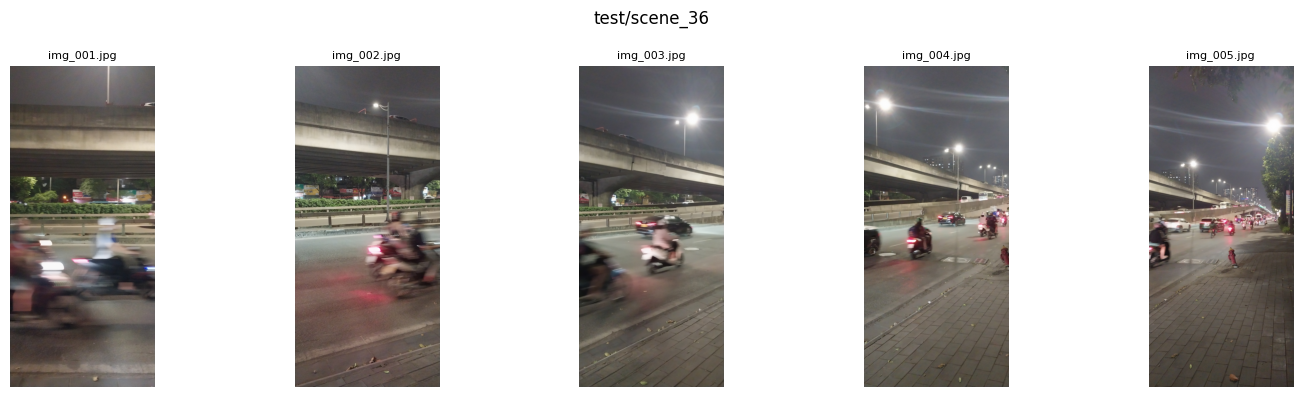

In [10]:
if SHOW_INPUT_STRIP:
    preview_scene(SCENE_ID, split_name=SCENE_SPLIT)


## Run One Scene

Cell này chạy OpenCV Stitcher cho đúng một scene, hiển thị:
- status của stitcher
- metadata của scene
- pair diagnostics
- panorama nếu ghép thành công

### test/scene_36 | `OK`

**Scene problems:** `motion_blur, moving_objects, output_variation, parallax, translation_capture`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_001.jpg,img_002.jpg,4000,44,14,0.318,True,1.729,weak
1,2,img_002.jpg,img_003.jpg,4000,93,53,0.570,True,1.571,strong
2,3,img_003.jpg,img_004.jpg,4000,89,55,0.618,True,1.033,strong
3,4,img_004.jpg,img_005.jpg,4000,260,177,0.681,True,1.133,strong


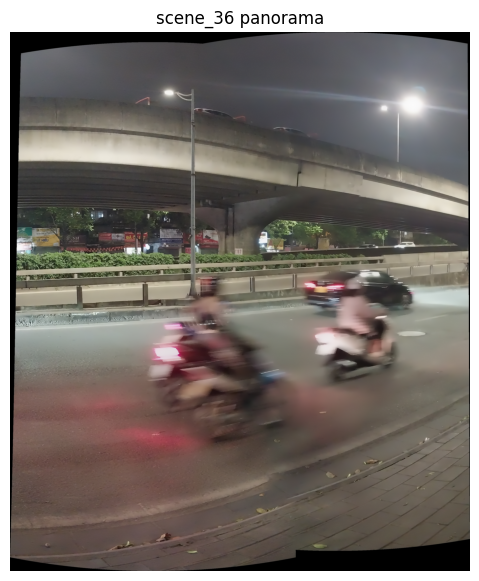

,split,scene_id,num_images,meta_capture_group,meta_category,meta_difficulty,meta_issues,meta_problem_flags,meta_stitcher_status,meta_ok_rate,meta_stability_label,meta_output_consistent,status_name,panorama_shape,panorama_path,log_path
0,test,scene_36,5,core,hard_valid,medium,"motion_blur, moving_objects, output_variation,...","moving_objects, parallax, motion_blur",OK,1.0,success_with_output_variation,False,OK,"{'width': 2984, 'height': 3502}",C:\Users\PC\Downloads\Project\outputs\openCV\p...,C:\Users\PC\Downloads\Project\outputs\openCV\l...


**Scene problems:** `motion_blur, moving_objects, output_variation, parallax, translation_capture`

**Scene notes:** Night sidewalk capture under an overpass with heavy moving traffic and a walking-style translated viewpoint. OpenCV usually succeeds, but motion blur, moving objects, and mild output variation keep it in hard-valid territory.

**Metadata stability:** success_with_output_variation | ok_rate=1.0 | output_consistent=False

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_001.jpg,img_002.jpg,4000,44,14,0.318,True,1.729,weak
1,2,img_002.jpg,img_003.jpg,4000,93,53,0.570,True,1.571,strong
2,3,img_003.jpg,img_004.jpg,4000,89,55,0.618,True,1.033,strong
3,4,img_004.jpg,img_005.jpg,4000,260,177,0.681,True,1.133,strong


In [11]:
single_result = run_scene(
    scene_id=SCENE_ID,
    split_name=SCENE_SPLIT,
    max_input_width=MAX_INPUT_WIDTH,
    mode_name=STITCHER_MODE,
    save_outputs=SAVE_OUTPUTS,
)

display(pd.DataFrame([
    {
        "split": single_result["split"],
        "scene_id": single_result["scene_id"],
        "num_images": single_result["num_images"],
        "meta_capture_group": single_result["meta_capture_group"],
        "meta_category": single_result["meta_category"],
        "meta_difficulty": single_result["meta_difficulty"],
        "meta_issues": single_result["meta_issues"],
        "meta_problem_flags": single_result["meta_problem_flags"],
        "meta_stitcher_status": single_result["meta_stitcher_status"],
        "meta_ok_rate": single_result["meta_ok_rate"],
        "meta_stability_label": single_result["meta_stability_label"],
        "meta_output_consistent": single_result["meta_output_consistent"],
        "status_name": single_result["status_name"],
        "panorama_shape": single_result["panorama_shape"],
        "panorama_path": single_result["panorama_path"],
        "log_path": single_result["log_path"],
    }
]))

display(Markdown(f"**Scene problems:** `{single_result['meta_issues']}`" if single_result["meta_issues"] else "**Scene problems:** none recorded in `meta.json`."))
display(Markdown(f"**Scene notes:** {single_result['meta_notes']}" if single_result["meta_notes"] else "**Scene notes:** none"))
display(
    Markdown(
        f"**Metadata stability:** {single_result['meta_stability_label']} | "
        f"ok_rate={single_result['meta_ok_rate']} | "
        f"output_consistent={single_result['meta_output_consistent']}"
        if single_result["meta_stability_label"] is not None
        else "**Metadata stability:** none"
    )
)
display(pd.DataFrame(single_result["pair_diagnostics"]))

,split,scene_id,overlay_path,log_path,num_images,num_reference_images
0,test,scene_36,C:\Users\PC\Downloads\Project\outputs\openCV\o...,C:\Users\PC\Downloads\Project\outputs\openCV\l...,5,0


,file,method,good_matches,inliers,inlier_ratio,confidence,match_hull_area_ratio,projected_area_ratio
0,img_001.jpg,sift_clahe,125,28,0.224,high,0.0070,0.0001
1,img_002.jpg,orb_clahe,3167,2155,0.680,high,0.0827,0.7365
2,img_003.jpg,orb_clahe,1053,780,0.741,high,0.0327,0.7187
3,img_004.jpg,orb_clahe,50,16,0.320,medium,0.0013,NaN
4,img_005.jpg,sift_clahe,77,13,0.169,medium,0.0022,0.0000


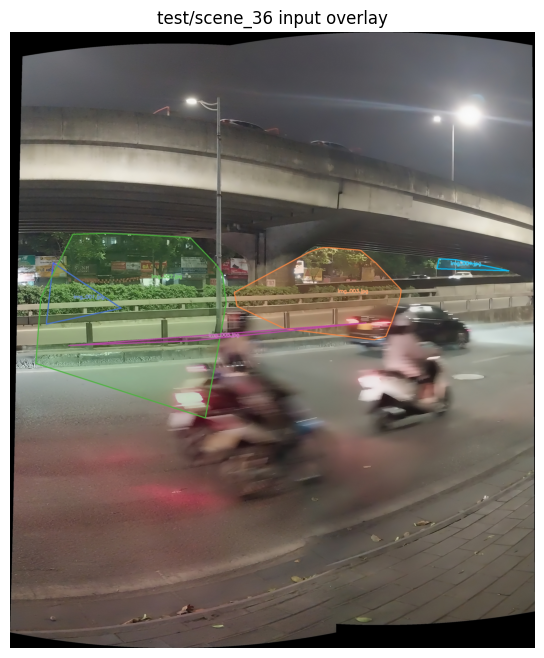

In [12]:
from scripts.PhamHungSon_15_generate_opencv_overlay import generate_overlay

overlay_result = generate_overlay(SCENE_ID, split_name=SCENE_SPLIT)

display(pd.DataFrame([
    {
        "split": overlay_result["split"],
        "scene_id": overlay_result["scene_id"],
        "overlay_path": overlay_result["overlay_path"],
        "log_path": overlay_result["log_path"],
        "num_images": len(overlay_result["ordered_files"]),
        "num_reference_images": len(overlay_result["reference_files"]),
    }
]))

overlay_df = pd.DataFrame(overlay_result["per_image_overlay"])
if not overlay_df.empty:
    display(
        overlay_df[
            [
                "file",
                "method",
                "good_matches",
                "inliers",
                "inlier_ratio",
                "confidence",
                "match_hull_area_ratio",
                "projected_area_ratio",
            ]
        ]
    )

overlay_image = cv2.imread(overlay_result["overlay_path"])
if overlay_image is None:
    print("Could not read overlay image.")
else:
    plt.figure(figsize=(16, 8))
    plt.imshow(bgr_to_rgb(overlay_image))
    plt.title(f"{SCENE_SPLIT}/{SCENE_ID} input overlay")
    plt.axis("off")
    plt.show()

## Run All Scenes

Cell nay chi chay khi `RUN_ALL_SCENES = True`.

No se:
- stitch toan bo scene trong `data/split`
- luu tung summary JSON rieng le
- tao mot file CSV tong hop trong `outputs/openCV/logs/`

Running all split scenes with STITCHER_MODE=PANORAMA ...
Running failure_analysis/scene_03 ...


### failure_analysis/scene_03 | `OK`

**Scene problems:** `wrong_image_order, sequence_order_error, output_variation`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_01.jpg,img_02.jpg,4000,250,127,0.508,True,1.725,strong
1,2,img_02.jpg,img_03.jpg,4000,129,68,0.527,True,1.829,strong
2,3,img_03.jpg,img_04.jpg,4000,252,155,0.615,True,1.440,strong


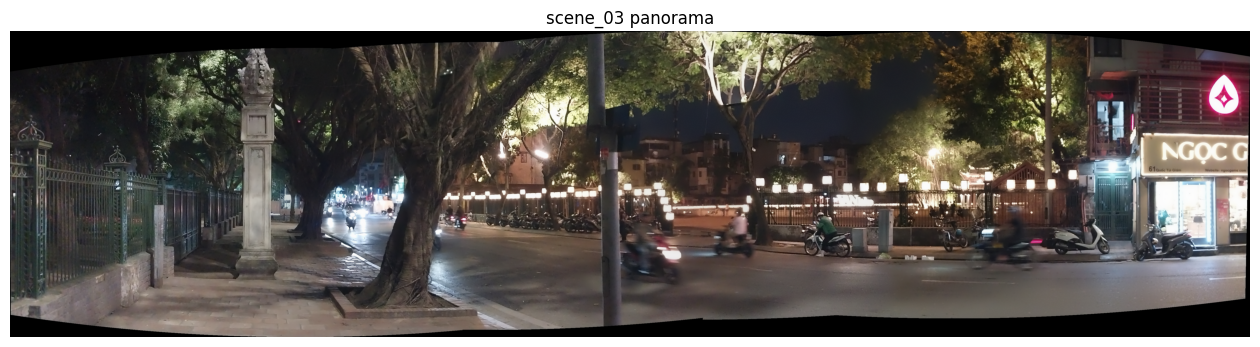

Running failure_analysis/scene_04 ...


### failure_analysis/scene_04 | `ERR_NEED_MORE_IMGS`

**Scene problems:** `insufficient_overlap`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_01.jpg,img_02.jpg,4000,23,7,0.304,False,0.597,fail
1,2,img_02.jpg,img_03.jpg,4000,59,23,0.390,True,1.638,ok


Stitcher did not return a panorama image.
Running failure_analysis/scene_06 ...


### failure_analysis/scene_06 | `OK`

**Scene problems:** `sky_dominance, low_texture`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_001.jpg,img_002.jpg,3944,465,401,0.862,True,1.075,strong
1,2,img_002.jpg,img_003.jpg,2991,138,95,0.688,True,1.286,strong
2,3,img_003.jpg,img_004.jpg,1147,84,59,0.702,True,1.262,strong
3,4,img_004.jpg,img_005.jpg,1078,179,159,0.888,True,1.169,strong


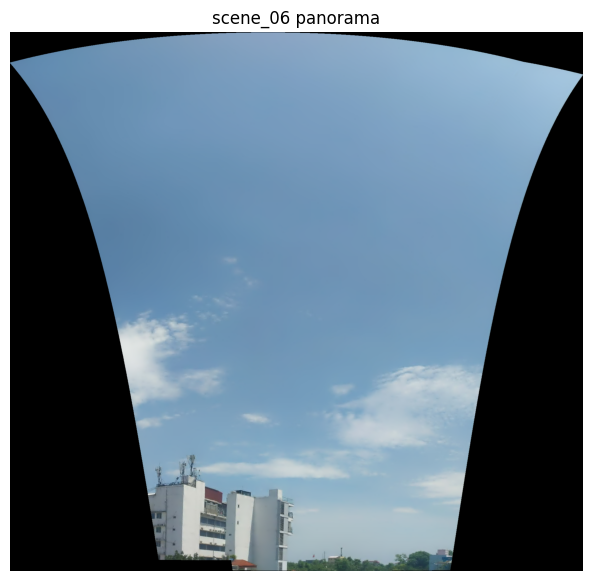

Running failure_analysis/scene_07 ...


### failure_analysis/scene_07 | `OK`

**Scene problems:** `zoom_change, scale_change`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_001.jpg,img_002.jpg,3848,325,258,0.794,True,1.177,strong
1,2,img_002.jpg,img_003.jpg,4000,439,292,0.665,True,1.168,strong
2,3,img_003.jpg,img_004.jpg,4000,269,198,0.736,True,0.980,strong
3,4,img_004.jpg,img_005.jpg,4000,576,513,0.891,True,1.138,strong
4,5,img_005.jpg,img_006.jpg,4000,335,291,0.869,True,1.498,strong


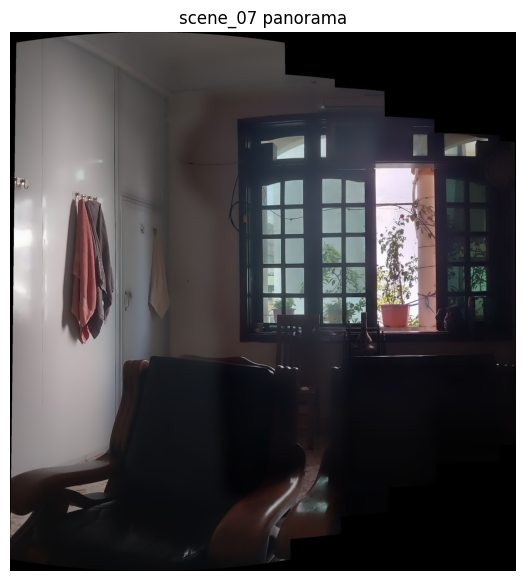

Running failure_analysis/scene_08 ...


### failure_analysis/scene_08 | `ERR_NEED_MORE_IMGS`

**Scene problems:** `global_stitch_failure`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_01.jpg,img_02.jpg,4000,227,155,0.683,True,0.876,strong
1,2,img_02.jpg,img_03.jpg,4000,187,120,0.642,True,1.119,strong


Stitcher did not return a panorama image.
Running failure_analysis/scene_11 ...


...

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_01.jpg,img_02.jpg,4000,121,44,0.364,True,1.734,ok
1,2,img_02.jpg,img_03.jpg,4000,338,91,0.269,True,2.121,ok
2,3,img_03.jpg,img_04.jpg,4000,148,23,0.155,True,1.076,weak
3,4,img_04.jpg,img_05.jpg,4000,465,222,0.477,True,1.355,strong


Stitcher did not return a panorama image.
Running failure_analysis/scene_16 ...


### failure_analysis/scene_16 | `OK`

**Scene problems:** `camera_translation, vertical_camera_motion, horizontal_camera_motion, parallax`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_001.jpg,img_002.jpg,4000,194,137,0.706,True,1.558,strong
1,2,img_002.jpg,img_003.jpg,4000,185,85,0.459,True,1.290,strong
2,3,img_003.jpg,img_004.jpg,4000,630,400,0.635,True,1.415,strong


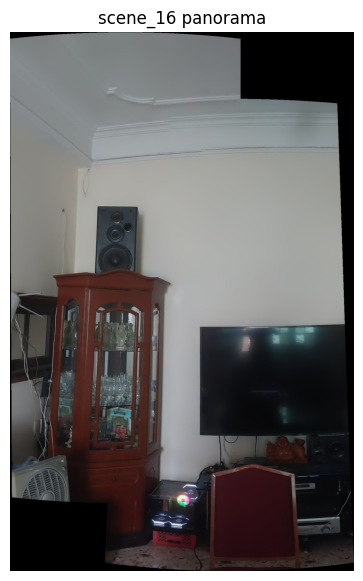

Running failure_analysis/scene_18 ...


### failure_analysis/scene_18 | `ERR_NEED_MORE_IMGS`

**Scene problems:** `low_light, exposure_compensation, underexposure, low_texture`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_001.jpg,img_002.jpg,0,0,0,0.000,False,NaN,fail
1,2,img_002.jpg,img_003.jpg,0,0,0,0.000,False,NaN,fail
2,3,img_003.jpg,img_004.jpg,0,0,0,0.000,False,NaN,fail
3,4,img_004.jpg,img_005.jpg,0,0,0,0.000,False,NaN,fail
4,5,img_005.jpg,img_006.jpg,9,0,0,0.000,False,NaN,fail
5,6,img_006.jpg,img_007.jpg,42,11,8,0.727,True,2.175,weak


Stitcher did not return a panorama image.
Running failure_analysis/scene_21 ...


### failure_analysis/scene_21 | `OK`

**Scene problems:** `exposure_change, low_texture, wide_sweep`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_01.jpg,img_02.jpg,4000,654,276,0.422,True,1.383,ok
1,2,img_02.jpg,img_03.jpg,4000,49,24,0.490,True,2.119,ok
2,3,img_03.jpg,img_04.jpg,4000,257,98,0.381,True,1.366,ok
3,4,img_04.jpg,img_05.jpg,4000,804,609,0.757,True,1.002,strong
4,5,img_05.jpg,img_06.jpg,4000,1114,730,0.655,True,1.134,strong
5,6,img_06.jpg,img_07.jpg,4000,1404,1021,0.727,True,0.993,strong
6,7,img_07.jpg,img_08.jpg,4000,61,40,0.656,True,0.809,strong
7,8,img_08.jpg,img_09.jpg,4000,490,224,0.457,True,1.218,strong
8,9,img_09.jpg,img_10.jpg,4000,477,399,0.836,True,0.946,strong
9,10,img_10.jpg,img_11.jpg,4000,214,89,0.416,True,1.748,ok


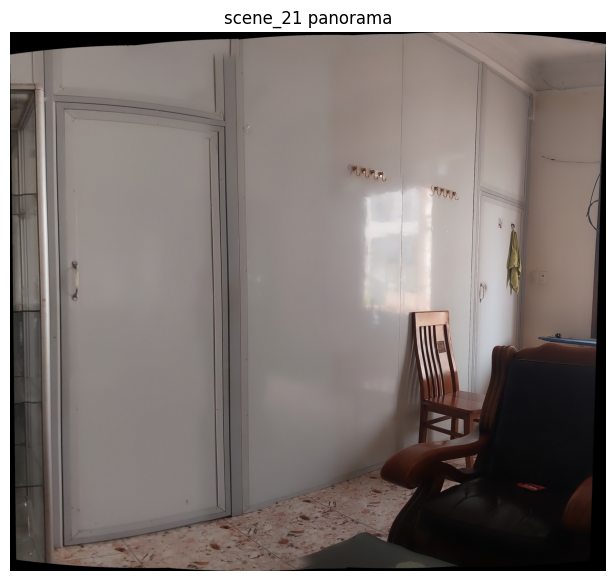

Running failure_analysis/scene_30 ...


### failure_analysis/scene_30 | `OK`

**Scene problems:** `exposure_change, output_variation, stitch_instability`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_01.jpg,img_02.jpg,4000,286,209,0.731,True,1.125,strong
1,2,img_02.jpg,img_03.jpg,4000,155,87,0.561,True,2.055,strong
2,3,img_03.jpg,img_04.jpg,4000,216,128,0.593,True,1.568,strong
3,4,img_04.jpg,img_05.jpg,4000,211,113,0.536,True,1.734,strong
4,5,img_05.jpg,img_06.jpg,4000,69,39,0.565,True,1.182,ok


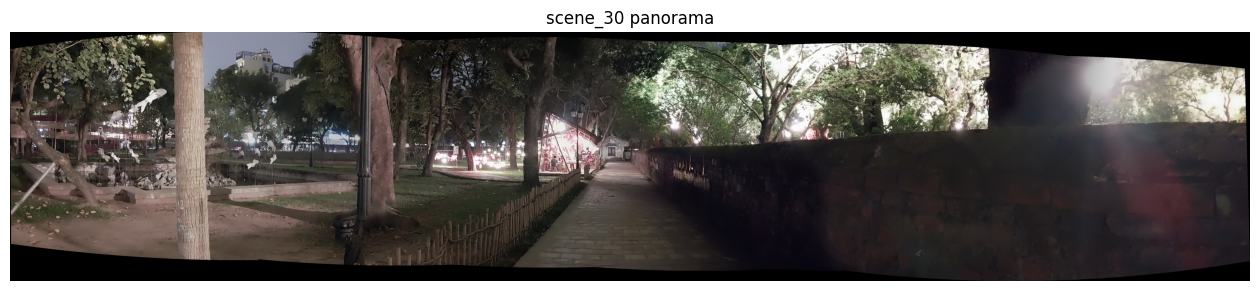

Running failure_analysis/scene_32 ...


### failure_analysis/scene_32 | `OK`

**Scene problems:** `repeated_patterns`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_01.jpg,img_02.jpg,4000,392,202,0.515,True,1.887,strong
1,2,img_02.jpg,img_03.jpg,4000,580,338,0.583,True,1.317,strong
2,3,img_03.jpg,img_04.jpg,4000,524,217,0.414,True,1.465,ok
3,4,img_04.jpg,img_05.jpg,4000,850,457,0.538,True,1.755,strong


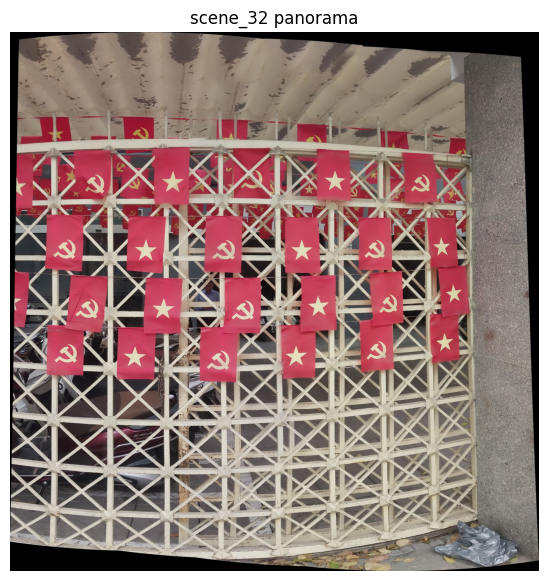

Running failure_analysis/scene_35 ...


### failure_analysis/scene_35 | `OK`

**Scene problems:** `motion_blur, moving_objects, output_variation`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_001.jpg,img_002.jpg,4000,107,71,0.664,True,1.366,strong
1,2,img_002.jpg,img_003.jpg,4000,493,337,0.684,True,1.247,strong
2,3,img_003.jpg,img_004.jpg,4000,136,43,0.316,True,0.981,ok


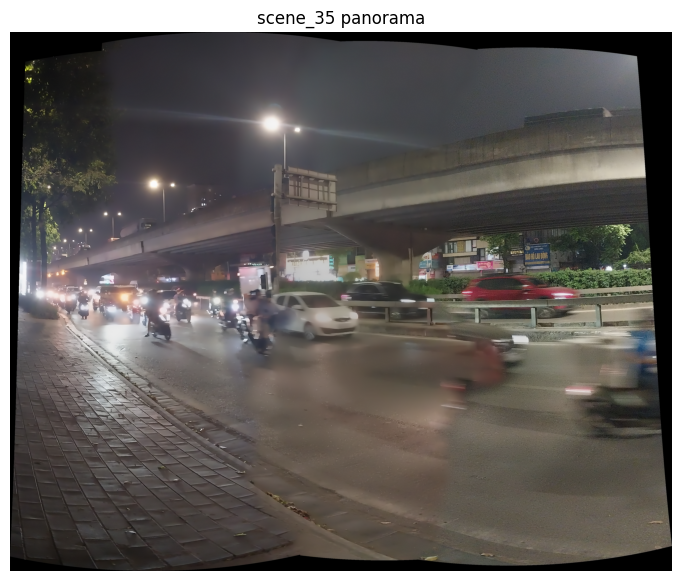

Running test/scene_01 ...


### test/scene_01 | `OK`

**Scene problems:** none recorded in `meta.json`.

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_01.jpg,img_02.jpg,4000,839,578,0.689,True,1.135,strong
1,2,img_02.jpg,img_03.jpg,4000,573,331,0.578,True,1.033,strong
2,3,img_03.jpg,img_04.jpg,4000,711,479,0.674,True,1.152,strong
3,4,img_04.jpg,img_05.jpg,4000,432,298,0.690,True,1.016,strong
4,5,img_05.jpg,img_06.jpg,4000,518,260,0.502,True,1.453,strong


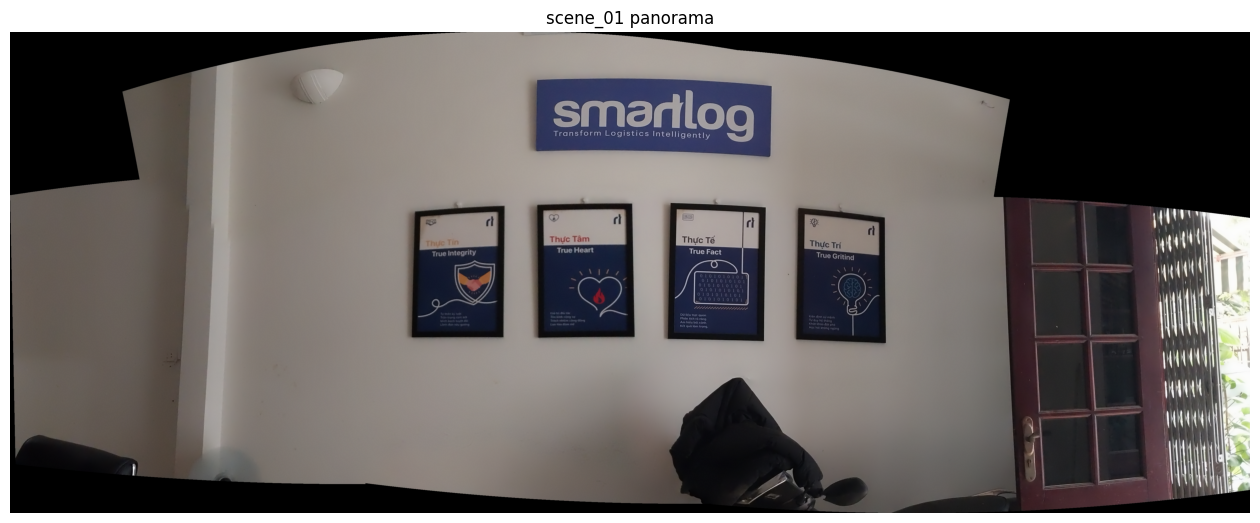

Running test/scene_24 ...


### test/scene_24 | `OK`

**Scene problems:** none recorded in `meta.json`.

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_01.jpg,img_02.jpg,4000,186,87,0.468,True,1.409,strong
1,2,img_02.jpg,img_03.jpg,4000,406,326,0.803,True,0.949,strong
2,3,img_03.jpg,img_04.jpg,4000,1337,855,0.639,True,1.778,strong
3,4,img_04.jpg,img_05.jpg,4000,1210,823,0.680,True,1.672,strong


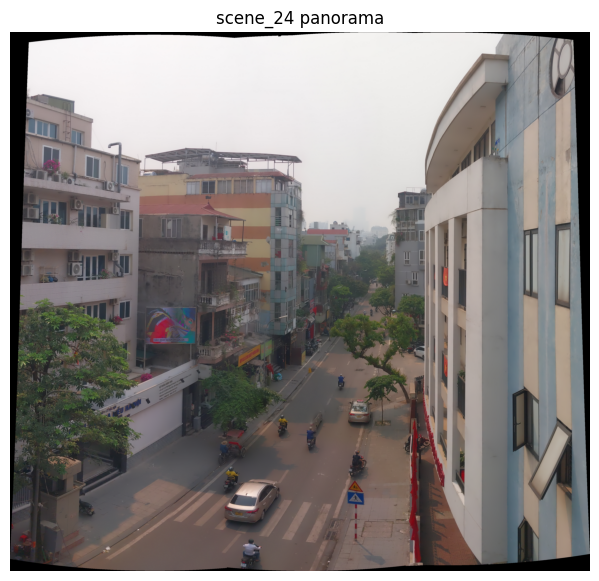

Running test/scene_28 ...


### test/scene_28 | `OK`

**Scene problems:** none recorded in `meta.json`.

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_01.jpg,img_02.jpg,4000,328,234,0.713,True,1.381,strong
1,2,img_02.jpg,img_03.jpg,4000,629,480,0.763,True,1.207,strong
2,3,img_03.jpg,img_04.jpg,4000,582,409,0.703,True,1.348,strong
3,4,img_04.jpg,img_05.jpg,4000,1061,743,0.700,True,1.350,strong
4,5,img_05.jpg,img_06.jpg,4000,537,401,0.747,True,1.265,strong


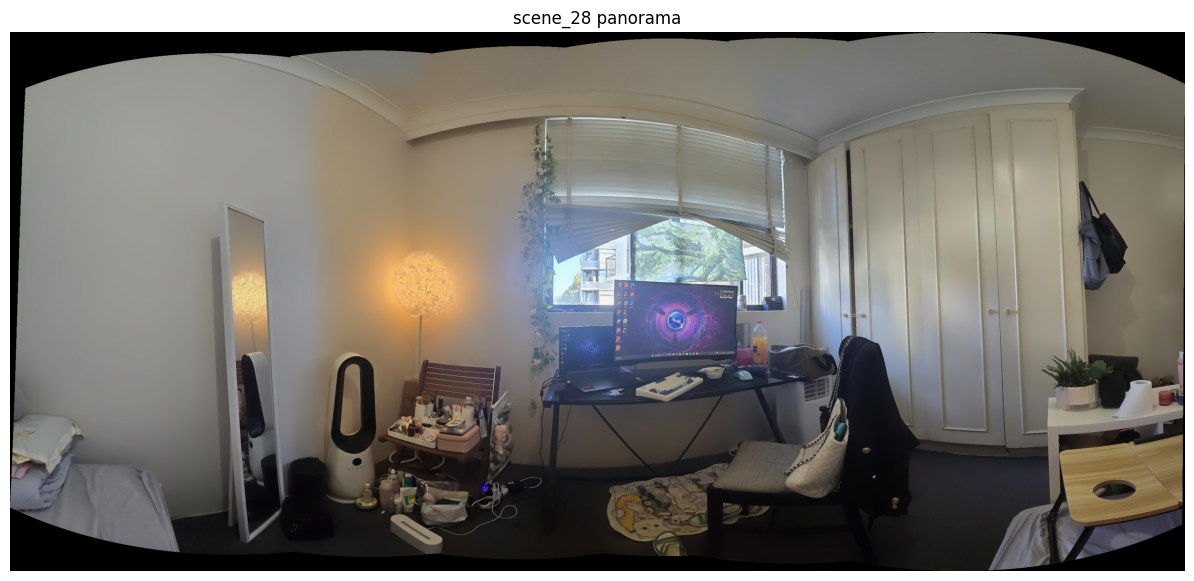

Running test/scene_33 ...


### test/scene_33 | `OK`

**Scene problems:** `repeated_patterns`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_01.jpg,img_02.jpg,4000,189,84,0.444,True,1.670,ok
1,2,img_02.jpg,img_03.jpg,4000,85,22,0.259,True,1.547,ok
2,3,img_03.jpg,img_04.jpg,4000,102,36,0.353,True,0.906,ok
3,4,img_04.jpg,img_05.jpg,4000,163,97,0.595,True,1.686,strong
4,5,img_05.jpg,img_06.jpg,4000,144,72,0.500,True,1.731,strong


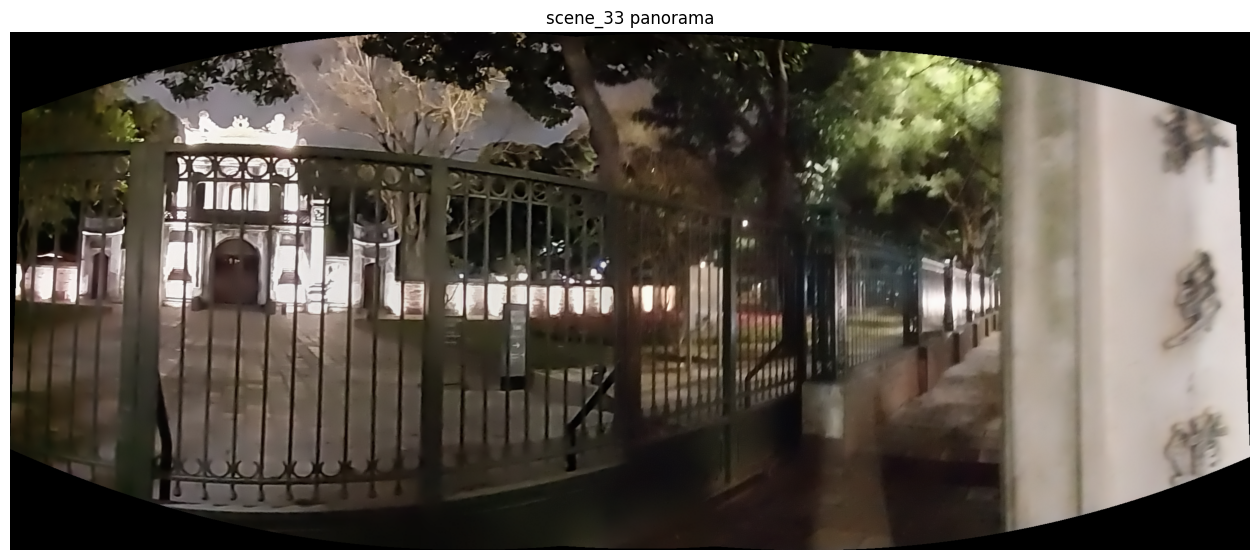

Running test/scene_36 ...


### test/scene_36 | `ERR_CAMERA_PARAMS_ADJUST_FAIL`

**Scene problems:** `motion_blur, moving_objects, output_variation, parallax, translation_capture`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_001.jpg,img_002.jpg,4000,44,14,0.318,True,1.729,weak
1,2,img_002.jpg,img_003.jpg,4000,93,53,0.570,True,1.571,strong
2,3,img_003.jpg,img_004.jpg,4000,89,55,0.618,True,1.033,strong
3,4,img_004.jpg,img_005.jpg,4000,260,177,0.681,True,1.133,strong


Stitcher did not return a panorama image.
Running test/scene_40 ...


### test/scene_40 | `OK`

**Scene problems:** `exposure_change, moving_objects, parallax, translation_capture`

,pair_index,image_a,image_b,raw_matches,good_matches,inliers,inlier_ratio,homography_ok,median_reproj_error,pair_label
0,1,img_001.jpg,img_002.jpg,4000,398,182,0.457,True,1.527,strong
1,2,img_002.jpg,img_003.jpg,4000,429,267,0.622,True,1.177,strong
2,3,img_003.jpg,img_004.jpg,4000,416,198,0.476,True,1.690,strong
3,4,img_004.jpg,img_005.jpg,4000,65,22,0.338,True,1.036,ok
4,5,img_005.jpg,img_006.jpg,4000,248,120,0.484,True,1.680,strong
5,6,img_006.jpg,img_007.jpg,4000,488,171,0.350,True,1.585,ok
6,7,img_007.jpg,img_008.jpg,4000,333,186,0.559,True,1.605,strong


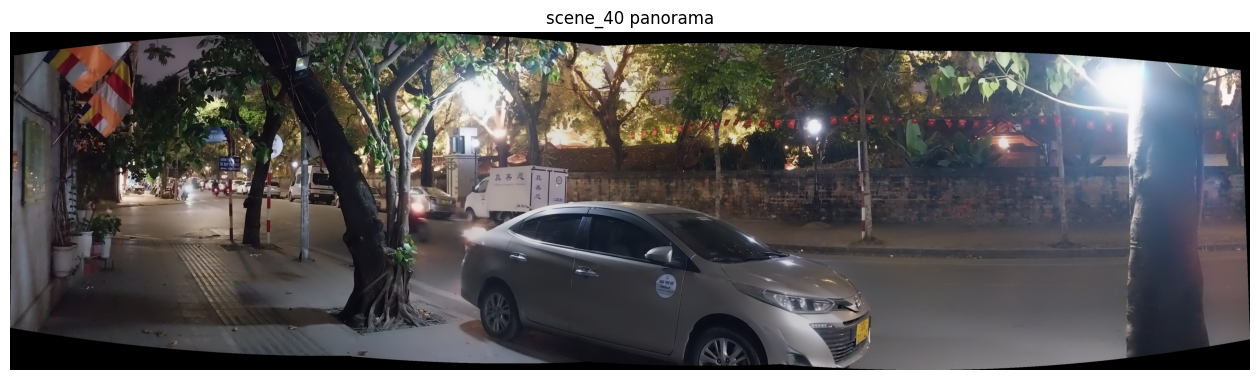

,split,scene_id,num_images,meta_capture_group,meta_category,meta_difficulty,meta_issues,meta_problem_flags,meta_stitcher_status,meta_ok_rate,meta_stability_label,meta_output_consistent,status_code,status_name,panorama_path,log_path
0,failure_analysis,scene_03,4,failure_analysis,hard_valid,hard,"wrong_image_order, sequence_order_error, outpu...",,OK,1.0,success_with_output_variation,False,0,OK,C:\Users\PC\Downloads\Project\outputs\openCV\p...,C:\Users\PC\Downloads\Project\outputs\openCV\l...
1,failure_analysis,scene_06,5,failure_analysis,hard_valid,hard,"sky_dominance, low_texture",low_texture,OK,1.0,stable_success,True,0,OK,C:\Users\PC\Downloads\Project\outputs\openCV\p...,C:\Users\PC\Downloads\Project\outputs\openCV\l...
2,failure_analysis,scene_07,6,failure_analysis,hard_valid,hard,"zoom_change, scale_change",,OK,1.0,stable_success,True,0,OK,C:\Users\PC\Downloads\Project\outputs\openCV\p...,C:\Users\PC\Downloads\Project\outputs\openCV\l...
3,failure_analysis,scene_16,4,failure_analysis,hard_valid,hard,"camera_translation, vertical_camera_motion, ho...",parallax,OK,1.0,stable_success,True,0,OK,C:\Users\PC\Downloads\Project\outputs\openCV\p...,C:\Users\PC\Downloads\Project\outputs\openCV\l...
4,failure_analysis,scene_21,13,large,hard_valid,hard,"exposure_change, low_texture, wide_sweep","low_texture, exposure_change",OK,1.0,success_with_output_variation,False,0,OK,C:\Users\PC\Downloads\Project\outputs\openCV\p...,C:\Users\PC\Downloads\Project\outputs\openCV\l...
5,failure_analysis,scene_30,6,core,hard_valid,hard,"exposure_change, output_variation, stitch_inst...",exposure_change,OK,1.0,success_with_output_variation,False,0,OK,C:\Users\PC\Downloads\Project\outputs\openCV\p...,C:\Users\PC\Downloads\Project\outputs\openCV\l...
6,failure_analysis,scene_32,5,failure_analysis,hard_valid,hard,repeated_patterns,repeated_patterns,OK,1.0,success_with_output_variation,False,0,OK,C:\Users\PC\Downloads\Project\outputs\openCV\p...,C:\Users\PC\Downloads\Project\outputs\openCV\l...
7,failure_analysis,scene_35,4,core,hard_valid,hard,"motion_blur, moving_objects, output_variation","moving_objects, motion_blur",OK,1.0,success_with_output_variation,False,0,OK,C:\Users\PC\Downloads\Project\outputs\openCV\p...,C:\Users\PC\Downloads\Project\outputs\openCV\l...
8,test,scene_01,6,core,success,medium,,,OK,1.0,stable_success,True,0,OK,C:\Users\PC\Downloads\Project\outputs\openCV\p...,C:\Users\PC\Downloads\Project\outputs\openCV\l...
9,test,scene_28,6,core,success,medium,,,OK,1.0,stable_success,True,0,OK,C:\Users\PC\Downloads\Project\outputs\openCV\p...,C:\Users\PC\Downloads\Project\outputs\openCV\l...


Saved batch summary to: C:\Users\PC\Downloads\Project\outputs\openCV\logs\batch_summary_panorama.csv


In [13]:
if RUN_ALL_SCENES:
    print(f"Running all split scenes with STITCHER_MODE={STITCHER_MODE} ...")
    batch_rows = []
    for _, scene_record in scene_table.iterrows():
        split_name = scene_record["split"]
        scene_id = scene_record["scene_id"]
        print(f"Running {split_name}/{scene_id} ...")
        result = run_scene(
            scene_id=scene_id,
            split_name=split_name,
            max_input_width=MAX_INPUT_WIDTH,
            mode_name=STITCHER_MODE,
            save_outputs=SAVE_OUTPUTS,
        )
        batch_rows.append(
            {
                "split": result["split"],
                "scene_id": result["scene_id"],
                "num_images": result["num_images"],
                "meta_capture_group": result["meta_capture_group"],
                "meta_category": result["meta_category"],
                "meta_difficulty": result["meta_difficulty"],
                "meta_issues": result["meta_issues"],
                "meta_problem_flags": result["meta_problem_flags"],
                "meta_stitcher_status": result["meta_stitcher_status"],
                "meta_ok_rate": result["meta_ok_rate"],
                "meta_stability_label": result["meta_stability_label"],
                "meta_output_consistent": result["meta_output_consistent"],
                "status_code": result["status_code"],
                "status_name": result["status_name"],
                "panorama_path": result["panorama_path"],
                "log_path": result["log_path"],
            }
        )
        del result
        gc.collect()

    batch_df = pd.DataFrame(batch_rows).sort_values(
        ["status_code", "split", "meta_ok_rate", "scene_id"],
        ascending=[True, True, False, True],
    ).reset_index(drop=True)
    batch_csv_path = OUTPUT_LOG_DIR / f"batch_summary_{STITCHER_MODE.lower()}.csv"
    batch_df.to_csv(batch_csv_path, index=False)
    display(batch_df)
    print("Saved batch summary to:", batch_csv_path)
else:
    print("Set RUN_ALL_SCENES = True and rerun this cell to stitch every scene.")

## Summary Notes

- Nếu một scene báo `ERR_NEED_MORE_IMGS`, thường nghĩa là OpenCV không thấy đủ ảnh/cặp đủ tin cậy để dựng panorama.
- Nếu báo `ERR_HOMOGRAPHY_EST_FAIL`, thường là một hoặc nhiều cặp không ước lượng được homography ổn định.
- Nếu báo `ERR_CAMERA_PARAMS_ADJUST_FAIL`, thường là ghép cặp cục bộ còn được nhưng tối ưu toàn chuỗi bị vỡ.
- Bạn có thể đổi `STITCHER_MODE` sang `SCANS` để thử xem scene nào hợp với kiểu scan hơn panorama.
- Nếu muốn so sánh với pipeline tự cài đặt, hãy giữ output của notebook này trong `outputs/openCV/` và để pipeline manual ghi vào `outputs/manual/`.